# Clasificación de Precios de Celulares con KNN y Árboles

Este notebook presenta la implementación de dos modelos de aprendizaje automático (K-Nearest Neighbors y Árboles de Decisión) para predecir el rango de precio de teléfonos móviles basándose en sus especificaciones técnicas.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Carga del dataset
# Asegurate de que el archivo 'train.csv' esté en la misma carpeta
df = pd.read_csv('train.csv')

# Visualización inicial
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


# Preprocesamiento de Datos
Dividimos los datos en características (X) y el objetivo (y). Luego, realizamos la partición en conjuntos de entrenamiento y prueba.

In [4]:
X = df.drop('price_range', axis=1)
y = df['price_range']

# Dividimos 80% para entrenar y 20% para testear
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Importante para KNN: Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Modelo 1: K-Nearest Neighbors (KNN)
KNN es un algoritmo basado en distancias. Utilizaremos los datos escalados para asegurar que todas las características influyan por igual.

Reporte de Clasificación - KNN:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       105
           1       0.34      0.45      0.39        91
           2       0.35      0.37      0.36        92
           3       0.81      0.54      0.65       112

    accuracy                           0.53       400
   macro avg       0.55      0.52      0.53       400
weighted avg       0.57      0.53      0.54       400



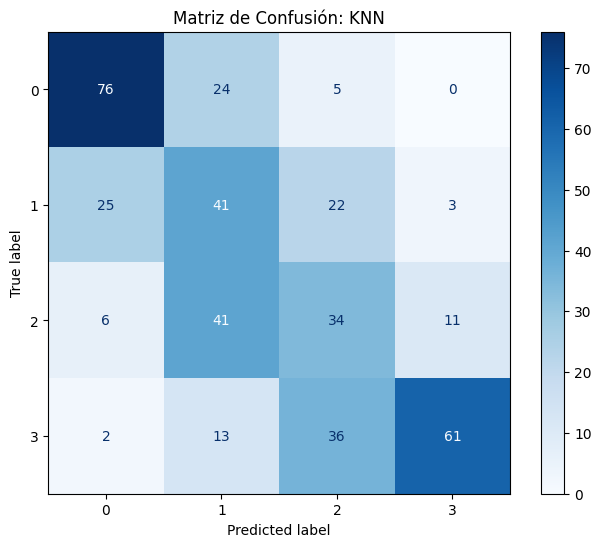

In [11]:
# Inicializamos el modelo con k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predicciones
y_pred_knn = knn.predict(X_test_scaled)

# Evaluación
print("Reporte de Clasificación - KNN:")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=ax, cmap='Blues')
plt.title("Matriz de Confusión: KNN")
plt.show()

# Arboles de Decisión
Los árboles de decisión permiten una interpretación visual muy clara de cómo se toman las decisiones según las variables (como la memoria RAM).

Reporte de Clasificación - Árbol de Decisión:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       105
           1       0.74      0.74      0.74        91
           2       0.63      0.72      0.67        92
           3       0.87      0.82      0.84       112

    accuracy                           0.80       400
   macro avg       0.79      0.79      0.79       400
weighted avg       0.80      0.80      0.80       400



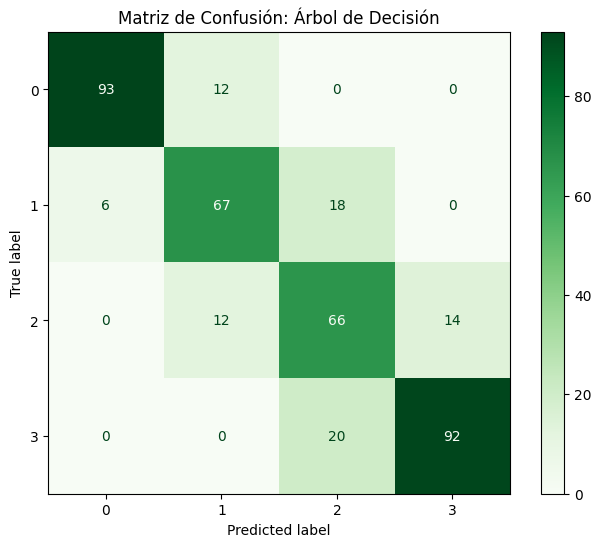

In [ ]:
# Inicializamos el árbol con una profundidad máxima para evitar sobreajuste
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Predicciones
y_pred_tree = tree_model.predict(X_test)

# Evaluación
print("Reporte de Clasificación - Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))

# Visualización de la Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=ax, cmap='Greens')
plt.title("Matriz de Confusión: Árbol de Decisión")
plt.show()

Visualización de la estructura del Árbol
Como se muestra en el material de clase, graficamos el árbol para entender las reglas de decisión:

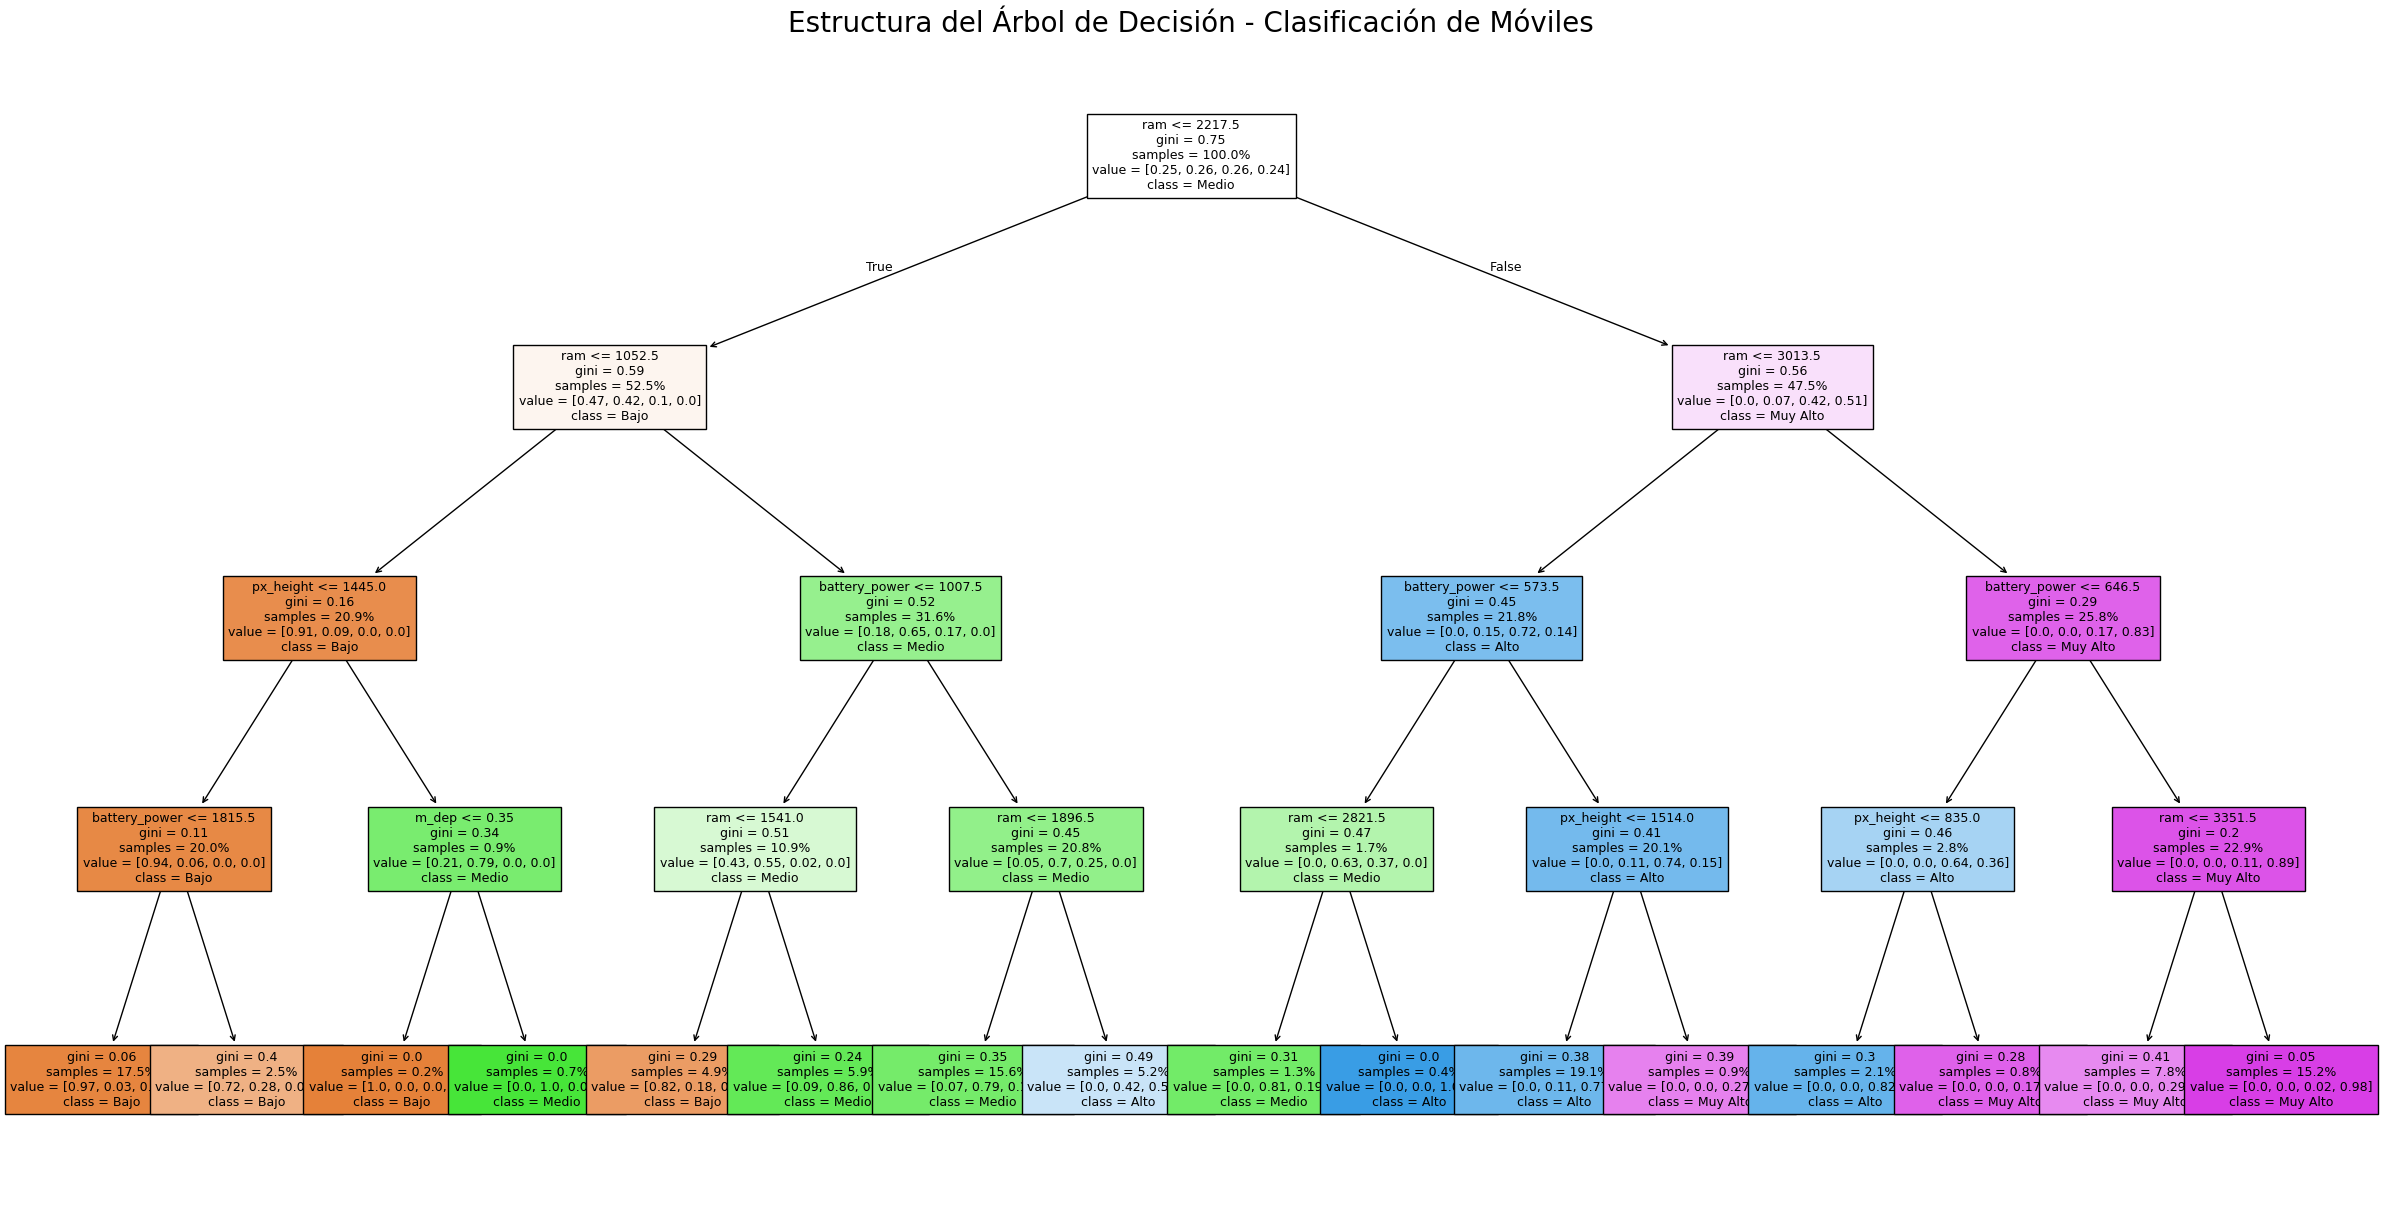

In [10]:
# Graficamos el árbol con ajustes de tamaño para evitar que se amontonen las hojas
plt.figure(figsize=(30, 15)) # Aumentamos mucho el ancho (30) y el alto (15)

plot_tree(tree_model, 
          feature_names=X.columns, 
          class_names=['Bajo', 'Medio', 'Alto', 'Muy Alto'], 
          filled=True, 
          fontsize=9,       # Fuente más chica para que el texto no desborde los cuadros
          precision=2,      # Solo dos decimales para achicar los nodos
          node_ids=False,   # No mostramos el ID del nodo para ahorrar espacio
          proportion=True)  # Mostramos porcentajes en lugar de valores absolutos largos

plt.title("Estructura del Árbol de Decisión - Clasificación de Móviles", fontsize=20)
plt.show()

## Conclusiones Comparativas a partir de los resultados obtenidos:

Rendimiento: (Completar según tus resultados, por ejemplo: "El modelo KNN mostró una precisión del XX% mientras que el Árbol alcanzó un XX%").

Importancia de Variables: En el gráfico del Árbol de Decisión, se observa que la variable ram es el principal nodo de decisión, lo cual tiene sentido lógico en el mercado de móviles.

Observaciones técnicas: El modelo KNN requirió obligatoriamente el escalado de datos para funcionar correctamente debido a la diferencia de magnitudes entre battery_power y otras variables.